In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model25_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model25_0)
describe(model25_0)

MACs: 4.52 MMac, Params: 32.13 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model25_0.pt
Starting
Epoch 1/60: Train loss = 1.1393, Train accuracy = 0.5901, Test loss = 1.1480, Test accuracy = 0.5895
Epoch 2/60: Train loss = 0.9896, Train accuracy = 0.6478, Test loss = 0.9804, Test accuracy = 0.6501
Epoch 3/60: Train loss = 0.8761, Train accuracy = 0.6865, Test loss = 0.9123, Test accuracy = 0.6818
Epoch 4/60: Train loss = 0.8230, Train accuracy = 0.7162, Test loss = 0.7966, Test accuracy = 0.7266
Epoch 5/60: Train loss = 0.7793, Train accuracy = 0.7285, Test loss = 0.7883, Test accuracy = 0.7265
Epoch 6/60: Train loss = 0.6878, Train accuracy = 0.7614, Test loss = 0.6860, Test accuracy = 0.7618
Epoch 7/60: Train loss = 0.6353, Train accuracy = 0.7775, Test loss = 0.6546, Test accuracy = 0.7740
Epoch 8/60: Train loss = 0.6334, Train accuracy = 0.7766, Test loss = 0.6538, Test accuracy = 0.7726
Epoch 9/60: Train loss = 0.6448, Train accuracy = 0.7727, Test loss = 0.6765, Test accuracy = 0.7712
Epoch 10/60: Train loss = 0.558

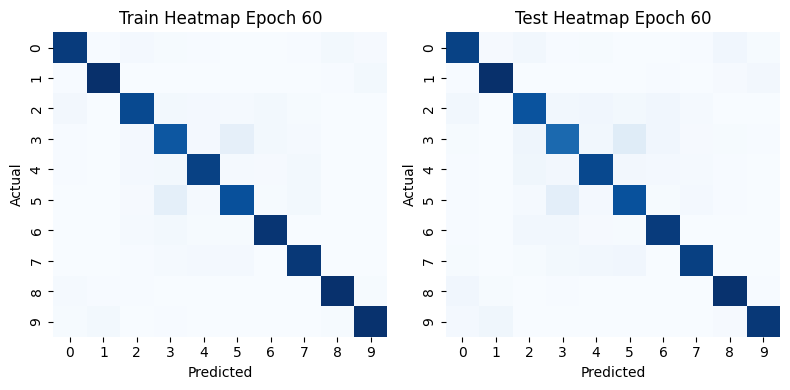

<Figure size 1200x600 with 0 Axes>

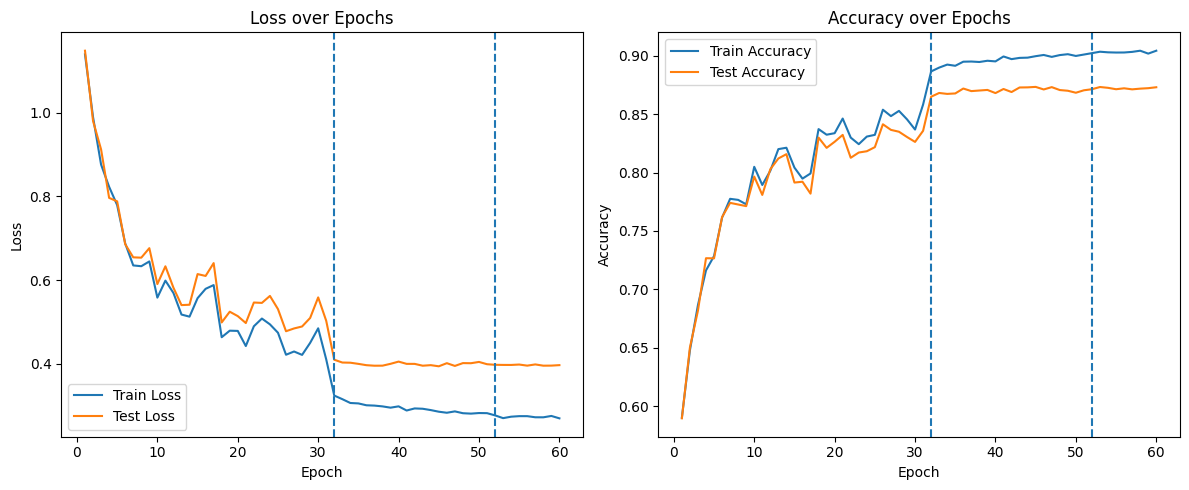

In [6]:
trainf32(model25_0,"model_weights/model25_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model25_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model25_1)
describe(model25_1)

MACs: 4.52 MMac, Params: 32.13 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1052, Train accuracy = 0.6152, Test loss = 1.0903, Test accuracy = 0.6230
Epoch 2/60: Train loss = 0.8588, Train accuracy = 0.6936, Test loss = 0.8166, Test accuracy = 0.7106
Epoch 3/60: Train loss = 0.7454, Train accuracy = 0.7391, Test loss = 0.7712, Test accuracy = 0.7355
Epoch 4/60: Train loss = 0.7137, Train accuracy = 0.7536, Test loss = 0.7146, Test accuracy = 0.7571
Epoch 5/60: Train loss = 0.6618, Train accuracy = 0.7715, Test loss = 0.6772, Test accuracy = 0.7716
Epoch 6/60: Train loss = 0.6567, Train accuracy = 0.7695, Test loss = 0.6979, Test accuracy = 0.7637
Epoch 7/60: Train loss = 0.6204, Train accuracy = 0.7857, Test loss = 0.6325, Test accuracy = 0.7796
Epoch 8/60: Train loss = 0.6250, Train accuracy = 0.7807, Test loss = 0.6597, Test accuracy = 0.7736
Epoch 9/60: Train loss = 0.6397, Train accuracy = 0.7765, Test loss = 0.6692, Test accuracy = 0.7697
Epoch 10/60: Train loss = 0.5649, Train accuracy = 0.8072, Test loss = 0.5908, Test accurac

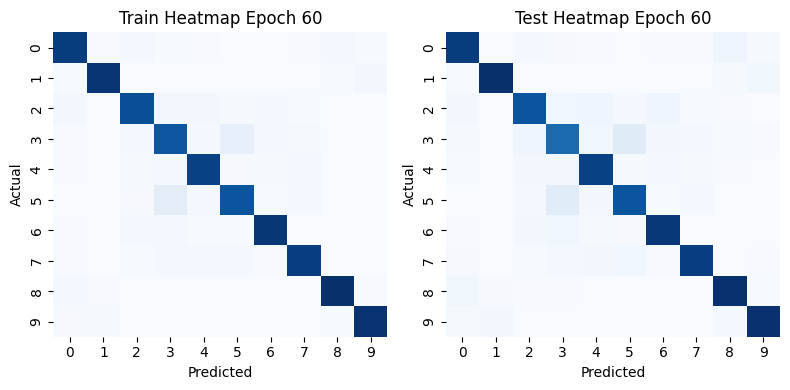

<Figure size 1200x600 with 0 Axes>

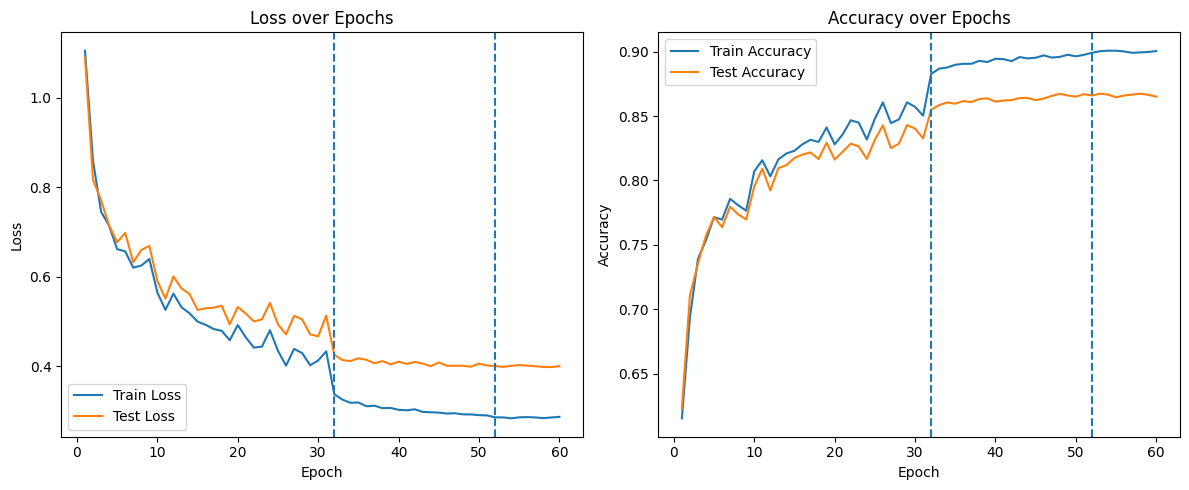

In [8]:
trainf32(model25_1,"model_weights/model25_1.pt",criterion,train_dataset,val_dataset, batch_size=64)